In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Exploratory Data Analysis (EDA)

In [45]:
data = pd.read_csv('titanic.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [46]:
data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [4]:
data.shape

(891, 12)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [47]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Overall Survival Rate: Approximately 38% of passengers survived the disaster.

In [48]:
data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

# Data cleaning

In [49]:
# Check for missing values
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [50]:
# Fill missing Age with median
data['Age'].dropna(inplace=True)

# Drop Cabin column (too many missing values)
data.drop('Cabin', axis=1, inplace=True)

# Fill missing Embarked with mode
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

C:\Users\My Computer\AppData\Local\Temp\ipykernel_31684\2764969843.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)


# Dealing with Outliers Using Boxplots

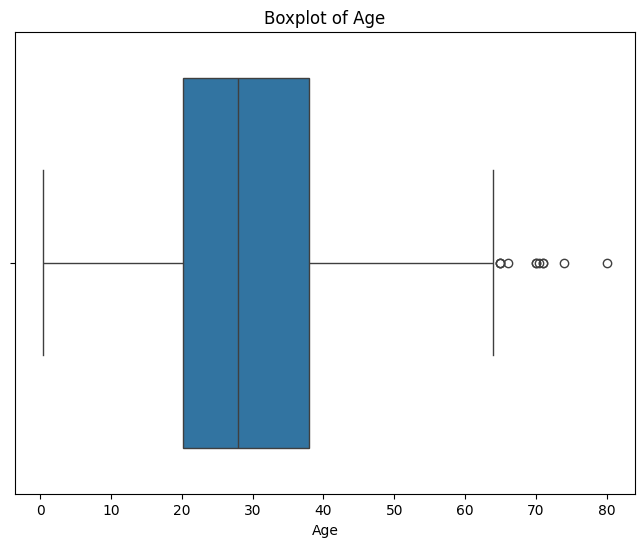

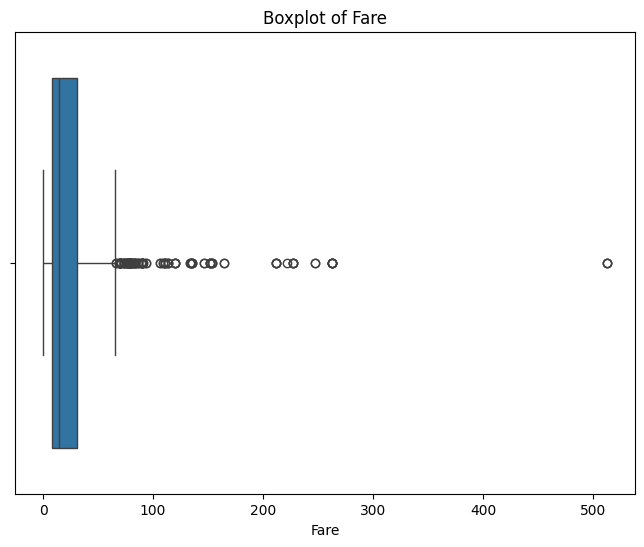

In [51]:
# Boxplot for 'Age'
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['Age'])
plt.title('Boxplot of Age')
plt.show()

# Boxplot for 'Fare'
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['Fare'])
plt.title('Boxplot of Fare')
plt.show()

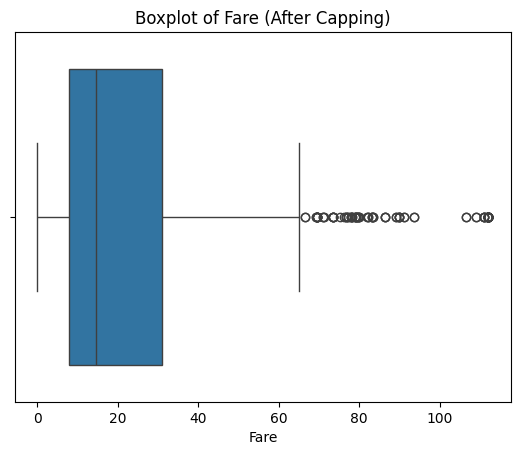

In [52]:
# Calculate the 95th percentile of 'Fare'
fare_95th_percentile = data['Fare'].quantile(0.95)

# Cap 'Fare' at the 95th percentile
data['Fare'] = data['Fare'].apply(lambda x: fare_95th_percentile if x > fare_95th_percentile else x)

# Verify the changes
sns.boxplot(x=data['Fare'])
plt.title('Boxplot of Fare (After Capping)')
plt.show()

# Dealing with Duplicate Data

In [53]:
# Check for duplicate rows
print(f"Number of duplicate rows: {data.duplicated().sum()}")

# Remove duplicate rows
data.drop_duplicates(inplace=True)

# Verify the changes
print(f"Number of duplicate rows after removal: {data.duplicated().sum()}")

Number of duplicate rows: 0
Number of duplicate rows after removal: 0


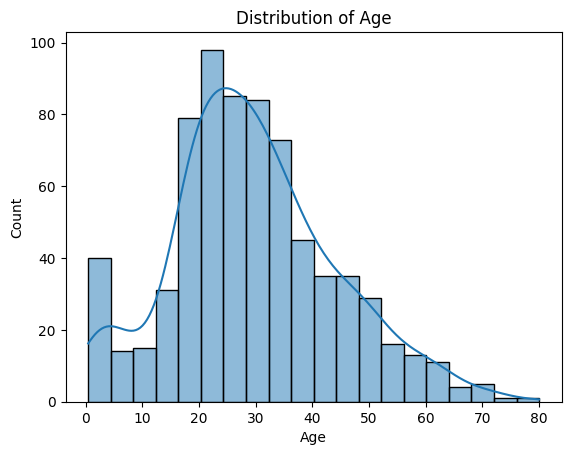

In [54]:
sns.histplot(data['Age'].dropna(), kde=True)
plt.title('Distribution of Age')
plt.show()

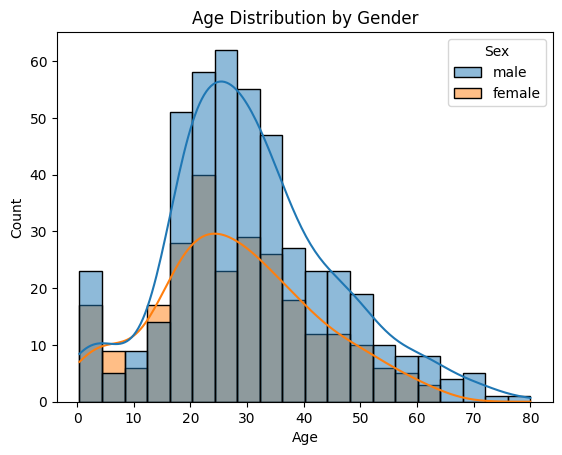

In [11]:
sns.histplot(data=data, x='Age', kde=True, hue='Sex')
plt.title('Age Distribution by Gender')
plt.show()

In [12]:
data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

As shown most of the passengers where male and the majority of passengers were between 20 and 40 years old.
Now let's analyze survival rates based on passenger class and gender

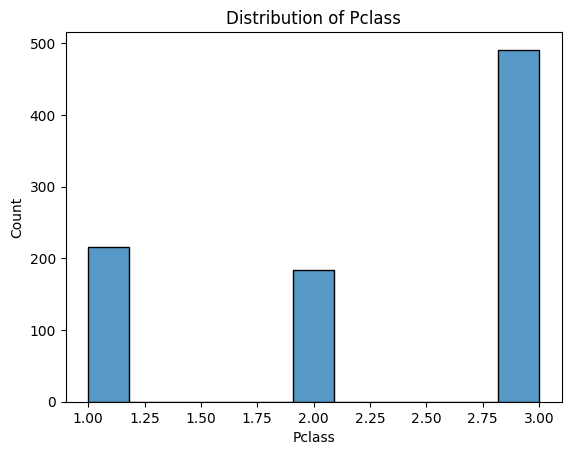

In [55]:
sns.histplot(data['Pclass'].dropna())
plt.title('Distribution of Pclass')
plt.show()

Diagram above shows that most of the passengers where in class 3

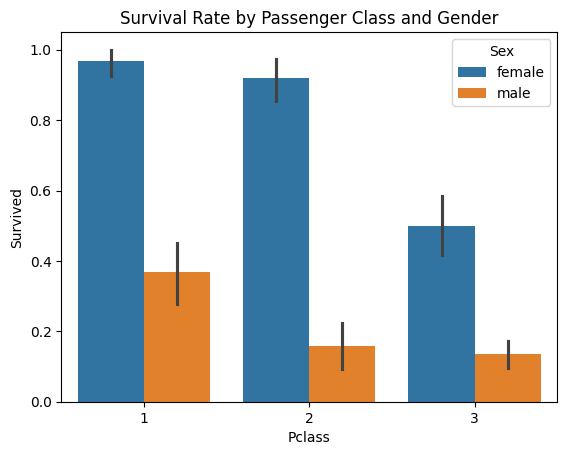

In [56]:
sns.barplot(data=data, x='Pclass', y='Survived', hue='Sex')
plt.title('Survival Rate by Passenger Class and Gender')
plt.show()

Fare and Survival:
Passengers who paid higher fares (first-class tickets) had a higher chance of survival.
Passengers who paid lower fares (third-class tickets) had a lower chance of survival.

Female passengers had a much higher survival rate (~74%) compared to male passengers (~19%).
First-class passengers had the highest survival rate (~63%).
Second-class passengers had a moderate survival rate (~47%).
Third-class passengers had the lowest survival rate (~24%).

In [108]:
data.groupby(['Sex'])['Survived'].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [109]:
data.groupby(['Pclass'])['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

<Axes: xlabel='Age', ylabel='Survived'>

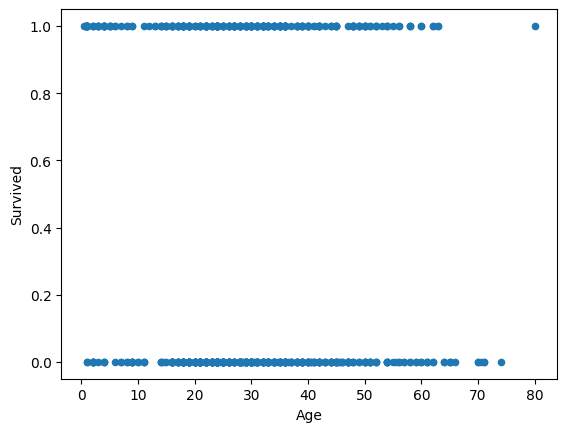

In [110]:
data.plot.scatter( x='Age' , y = 'Survived')

Children (ages 0-10) had a higher survival rate, likely due to the "women and children first" policy.
Elderly passengers (ages 60+) had a lower survival rate, possibly due to physical limitations during the evacuation.

# data preprocessing and converting everything to numerical values

In [57]:
# Drop unnecessary columns
data.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# Convert 'Sex' to numerical values using one-hot encoding
data = pd.get_dummies(data, columns=['Sex'], drop_first=True).replace([True,False],[1,0])  

# Convert 'Embarked' to numerical values using one-hot encoding
data = pd.get_dummies(data, columns=['Embarked'], drop_first=True).replace([True,False],[1,0])   

# Verify all features are numerical
print(data.dtypes)

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male        int64
Embarked_Q      int64
Embarked_S      int64
dtype: object


C:\Users\My Computer\AppData\Local\Temp\ipykernel_31684\1140673916.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = pd.get_dummies(data, columns=['Sex'], drop_first=True).replace([True,False],[1,0])
C:\Users\My Computer\AppData\Local\Temp\ipykernel_31684\1140673916.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = pd.get_dummies(data, columns=['Embarked'], drop_first=True).replace([True,False],[1,0])


# Data Normalization/Standardization

In [58]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
data2 = data[:]
# Normalize 'Age' and 'Fare' using MinMaxScaler
scaler = MinMaxScaler()
data2[['Age', 'Fare']] = scaler.fit_transform(data[['Age', 'Fare']])

# Standardize 'Age' and 'Fare' using StandardScaler
scaler = StandardScaler()
data[['Age', 'Fare']] = scaler.fit_transform(data[['Age', 'Fare']])

# Display the normalized/standardized dataset
data3 = data.head()
data3


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,-0.530377,1,0,-0.700836,1,0,1
1,1,1,0.571831,1,0,1.491434,0,0,0
2,1,3,-0.254825,0,0,-0.677726,0,0,1
3,1,1,0.365167,1,0,0.868903,0,0,1
4,0,3,0.365167,0,0,-0.673447,1,0,1


Data Normalization

In [59]:
data2.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,0.271174,1,0,0.064686,1,0,1
1,1,1,0.472229,1,0,0.636009,0,0,0
2,1,3,0.321438,0,0,0.070709,0,0,1
3,1,1,0.434531,1,0,0.473772,0,0,1
4,0,3,0.434531,0,0,0.071824,1,0,1


# Correlation Analysis

In [60]:
data3.corr()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
Survived,1.000000,-0.666667,0.360674,0.166667,NaN,0.654408,-1.000000,NaN,-0.408248
Pclass,-0.666667,1.000000,-0.707989,-0.666667,NaN,-0.977498,0.666667,NaN,0.612372
Age,0.360674,-0.707989,1.000000,0.093508,NaN,0.730448,-0.360674,NaN,-0.556257
SibSp,0.166667,-0.666667,0.093508,1.000000,NaN,0.644310,-0.166667,NaN,-0.408248
Parch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,0.654408,-0.977498,0.730448,0.644310,NaN,1.000000,-0.654408,NaN,-0.765174
Sex_male,-1.000000,0.666667,-0.360674,-0.166667,NaN,-0.654408,1.000000,NaN,0.408248
Embarked_Q,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Embarked_S,-0.408248,0.612372,-0.556257,-0.408248,NaN,-0.765174,0.408248,NaN,1.000000
